In [45]:
# This code is part of QCMet.
# 
# (C) Copyright 2024 National Physical Laboratory and National Quantum Computing Centre 
# 
# Licensed under the Apache License, Version 2.0 (the "License");
# you may not use this file except in compliance with the License.
# You may obtain a copy of the License at
# 
#      http://www.apache.org/licenses/LICENSE-2.0
# 
# Unless required by applicable law or agreed to in writing, software
# distributed under the License is distributed on an "AS IS" BASIS,
# WITHOUT WARRANTIES OR CONDITIONS OF ANY KIND, either express or implied.
# See the License for the specific language governing permissions and
# limitations under the License

## Standard deviation of a specified metric evaluated over a time interval

In [46]:
import sys
import os
import pathlib
from datetime import datetime
import time

import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from qiskit.providers.aer.noise import NoiseModel
from qiskit.providers.aer.noise import depolarizing_error

sys.path.insert(0, str(pathlib.Path(os.path.abspath('')).parent.parent.parent.resolve()))
from _helpers.circuit_submitter import *
sys.path.insert(0, str(pathlib.Path(os.path.abspath('')).parent.parent.parent.resolve()))
from tutorials.gate_execution_quality_metrics.randomized_benchmarking.rb import RandomizedBenchmarking

### Run RB with specified number of executions and intervals 

In [47]:
def basic_noise_model(dep1q=0.001, dep2q=0.01):
    noise = NoiseModel(basis_gates = ['cx', 'sx', 'rz','id'])
    depol_rz_error = 0.0000
    noise.add_all_qubit_quantum_error(depolarizing_error(depol_rz_error, 1), ["rz"])
    noise.add_all_qubit_quantum_error(depolarizing_error(dep1q, 1), ["sx"])
    noise.add_all_qubit_quantum_error(depolarizing_error(dep2q, 2), ["cx"])
    return noise


def gen_list_of_noise_models(seed=1010, num_noise_models=10):
    np.random.seed(seed)
    err2q = np.random.random_sample(size=(num_noise_models)) / 10
    err1q = np.random.random_sample(size=(num_noise_models)) / 100
    return (
        [basic_noise_model(dep1q=i, dep2q=j) for i, j in zip(err1q, err2q)],
        err1q,
        err2q,
    )

In [48]:
n_qubits = 1
n_cliffords = [1, 2, 4, 8, 16, 32, 64]
samples_per_depth = 20
shots = 1000
wait_seconds = 10
execution_number = 10
device_name = "noisy_sim"
benchmark_name = 'RB_fluctuations'

# these noise models is a basic example of how noise can change over time. 
noise_models = gen_list_of_noise_models(num_noise_models=execution_number)


ave_gate_err = []
execution_time_list = []

for i in range(execution_number):
    submitter = CircuitSubmitter(benchmark_name=f"{benchmark_name}/rb{i}", device_name=device_name)
    submitter.backend.device.set_noise_model(noise_model = noise_models[0][i])

    rb_experiment = RandomizedBenchmarking(n_qubits=n_qubits, n_cliffords=n_cliffords, samples_per_depth=samples_per_depth)
    all_circs = rb_experiment.generate_all_circuits()
    all_counts = {}
    shots = 10240
    for depth, circs in all_circs.items():
        t_circs = qiskit.transpile(circs, basis_gates = ['cx', 'id', 'rz', 'sx'])
        submitter.submit_circuits(shots, qasm_strs=[c.qasm() for c in t_circs], skip_asking=True, skip_transpilation=True)
        all_counts[depth] = [submitter.convert_counts_to_qiskit(counts) for counts in submitter.retrieve_counts()]
    rb_experiment.load_counts(all_counts, shots = shots)
    # a_0 * np.power(alpha, m) + b_0
    alpha, a_0, b_0 = 0.99,1,0
    initial_guess = (alpha, a_0, b_0) 
    rb_experiment.get_fit(initial_guess = initial_guess)
    average_gate_error = rb_experiment.get_average_gate_error()
    
    execution_time = datetime.now()
    execution_time_list.append(execution_time)
    ave_gate_err.append(average_gate_error)

    time.sleep(wait_seconds)

Ready to run 20 circuits on noisy_sim with 10240 shots.
Cost: 20 * ($0 + 10240 * $0) = $0.00.
Circuits have been submitted
2024-10-30 22:03:56 All circuits are finished
Ready to run 20 circuits on noisy_sim with 10240 shots.
Cost: 20 * ($0 + 10240 * $0) = $0.00.
Circuits have been submitted
2024-10-30 22:03:56 All circuits are finished
Ready to run 20 circuits on noisy_sim with 10240 shots.
Cost: 20 * ($0 + 10240 * $0) = $0.00.
Circuits have been submitted
2024-10-30 22:03:57 All circuits are finished
Ready to run 20 circuits on noisy_sim with 10240 shots.
Cost: 20 * ($0 + 10240 * $0) = $0.00.
Circuits have been submitted
2024-10-30 22:03:58 All circuits are finished
Ready to run 20 circuits on noisy_sim with 10240 shots.
Cost: 20 * ($0 + 10240 * $0) = $0.00.
Circuits have been submitted
2024-10-30 22:03:59 All circuits are finished
Ready to run 20 circuits on noisy_sim with 10240 shots.
Cost: 20 * ($0 + 10240 * $0) = $0.00.
Circuits have been submitted
2024-10-30 22:04:00 All circuits

In [49]:
print(f"Average error per {n_qubits}-qubit gate for each run:")
for i in range(execution_number):
    print(f"Run {i} executed on {execution_time_list[i].strftime('%Y-%m-%d %H:%M:%S')}, average error: {ave_gate_err[i]}")

Average error per 1-qubit gate for each run:
Run 0 executed on 2024-10-30 22:04:02, average error: 0.0026167060361204086
Run 1 executed on 2024-10-30 22:04:22, average error: 0.004262168669218025
Run 2 executed on 2024-10-30 22:04:42, average error: 0.00806653964354731
Run 3 executed on 2024-10-30 22:05:02, average error: 0.0021860170184629935
Run 4 executed on 2024-10-30 22:05:22, average error: 0.00695502177679691
Run 5 executed on 2024-10-30 22:05:42, average error: 0.0009835764292266402
Run 6 executed on 2024-10-30 22:06:02, average error: 0.004869256999658955
Run 7 executed on 2024-10-30 22:06:22, average error: 0.005721515549630518
Run 8 executed on 2024-10-30 22:06:41, average error: 0.005628335003989293
Run 9 executed on 2024-10-30 22:07:02, average error: 0.0020659869121044117


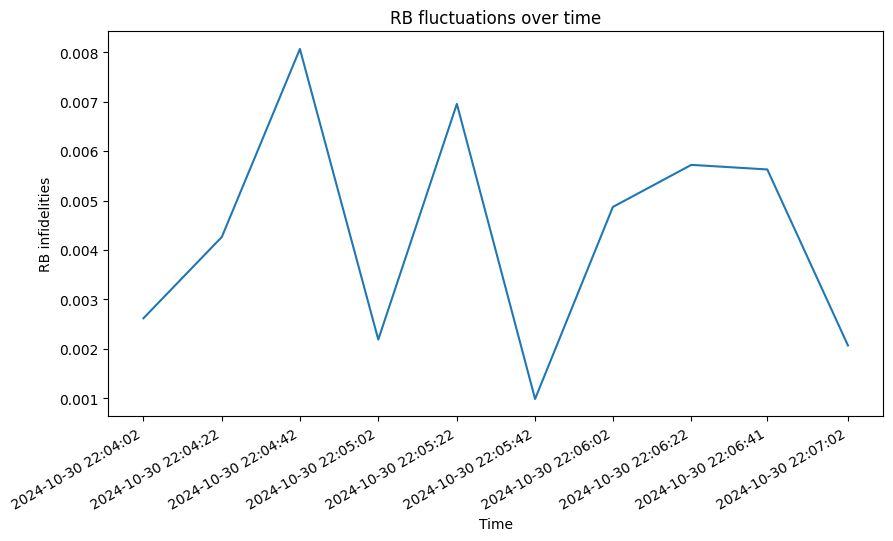

In [50]:
fig = plt.figure(figsize=(10, 5))
plt.plot(execution_time_list, ave_gate_err)
plt.xlabel('Time')
plt.ylabel('RB infidelities')
plt.title('RB fluctuations over time')
plt.xticks(execution_time_list)
axes = plt.gca()
axes.xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m-%d %H:%M:%S'))
for label in axes.get_xticklabels(which='major'):
    label.set(rotation=30, horizontalalignment='right')
plt.savefig('rb_fluctuations.png', bbox_inches = "tight")